<a href="https://colab.research.google.com/github/abdullaawad/Medical-Insurance-Project/blob/main/Medical_Insurance_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rahulvyasm/medical-insurance-cost-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'medical-insurance-cost-prediction' dataset.
Path to dataset files: /kaggle/input/medical-insurance-cost-prediction


# **Problem Statement:**

## What are the primary factors influencing medical expenses?



## How accurate are machine learning models in predicting medical expenses?



## In what ways can machine learning models enhance the efficiency and profitability of health insurance companies?

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv('/content/medical_insurance.csv')

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [34]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [35]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


## **What are the primary factors influencing medical expenses?**

## **Age:**

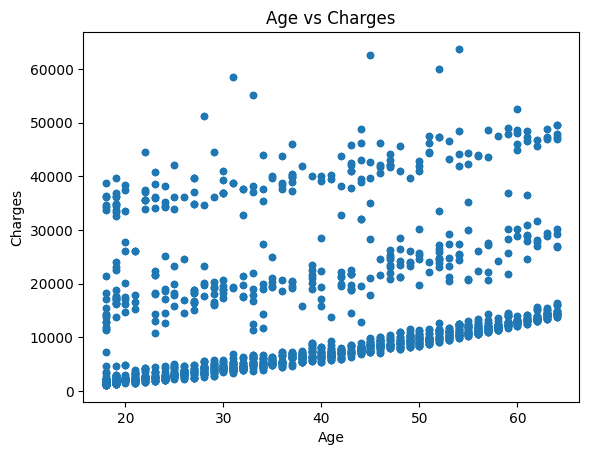

In [36]:
df.plot(x='age', y='charges', kind='scatter')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Age vs Charges')
plt.show()

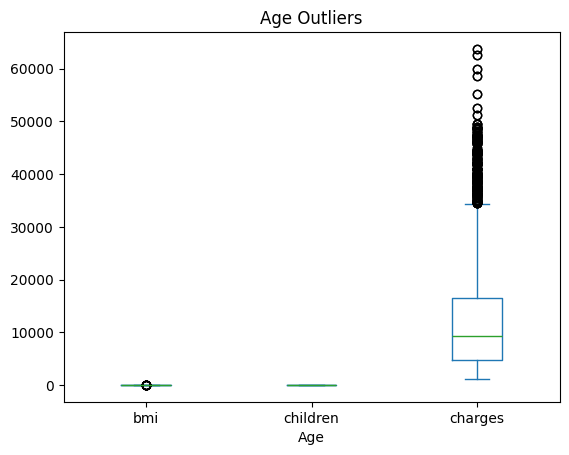

In [37]:
df.plot(x='age', kind='box')
plt.xlabel('Age')
plt.title('Age Outliers')
plt.show()

In [38]:
import plotly.express as px

age_outliers = px.box(df, x='age')
age_outliers.show()

## **Sex**

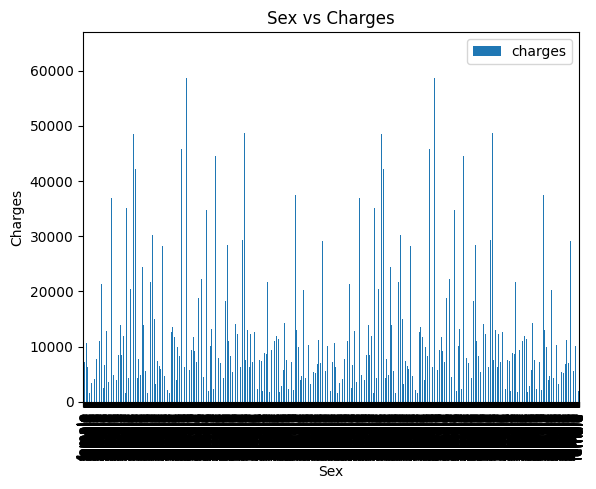

In [39]:
df.plot(x='sex', y='charges', kind='bar')
plt.xlabel('Sex')
plt.ylabel('Charges')
plt.title('Sex vs Charges')
plt.show()

In [40]:
sex_distribution = px.histogram(df, x='sex', y = 'charges')
sex_distribution

In [41]:
sex_count = df['sex'].value_counts()
sex_count

,count
sex,
male,1406
female,1366


In [42]:
avg_charges_per_region = df.groupby('region')['charges'].mean()
avg_charges_per_region

,charges
region,
northeast,13475.874737
northwest,12463.129315
southeast,14748.777706
southwest,12164.196435


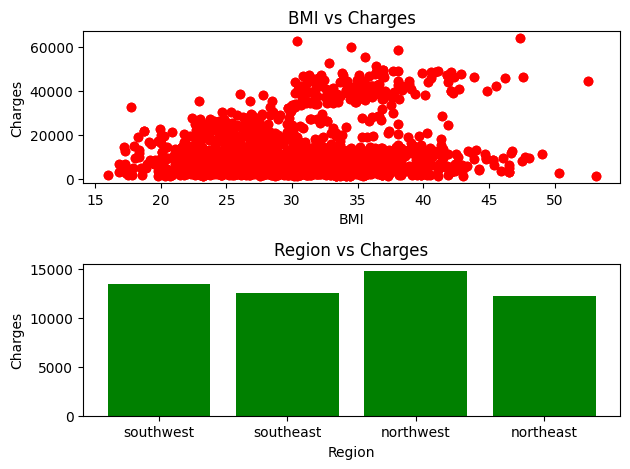

In [43]:
fig, ax = plt.subplots(2, 1)

ax[0].scatter(df['bmi'], df['charges'], color='r')
ax[0].set_xlabel('BMI')
ax[0].set_ylabel('Charges')
ax[0].set_title('BMI vs Charges')

ax[1].bar(df['region'].unique(), avg_charges_per_region, color='g')
ax[1].set_xlabel('Region')
ax[1].set_ylabel('Charges')
ax[1].set_title('Region vs Charges')

plt.tight_layout()
plt.show()

In [44]:
avg_charges_per_child = df.groupby('children')['charges'].mean()
avg_charges_per_child

,charges
children,
0,12317.920881
1,12722.650521
2,15268.182723
3,15304.070620
4,13550.983876
5,8706.036629


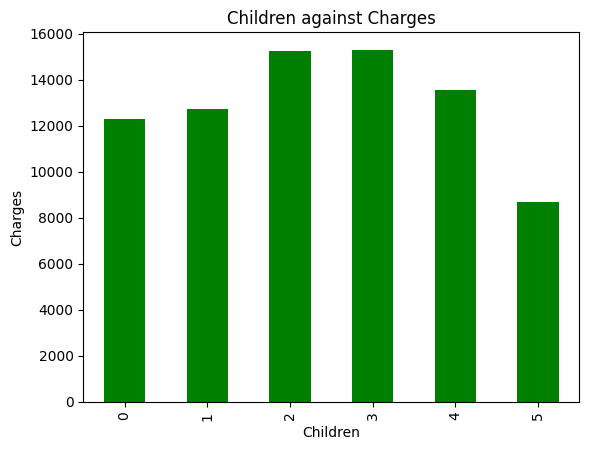

In [45]:
avg_charges_per_child.plot(kind='bar', color='g')
plt.xlabel('Children')
plt.ylabel('Charges')
plt.title('Children against Charges')
plt.show()

# **Implementing Machine Learning Algorithms:**

In [46]:
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()

label_encoder = preprocessing.LabelEncoder()
df['sex']= label_encoder.fit_transform(df['sex'])

df['smoker']= label_encoder.fit_transform(df['smoker'])

df['region']= label_encoder.fit_transform(df['region'])

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=20, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,2772.0,39.109668,14.081459,18.0000,26.000,39.00000,51.0000,64.00000
sex,2772.0,0.507215,0.500038,0.0000,0.000,1.00000,1.0000,1.00000
bmi,2772.0,30.701349,6.129449,15.9600,26.220,30.44750,34.7700,53.13000
children,2772.0,1.101732,1.214806,0.0000,0.000,1.00000,2.0000,5.00000
smoker,2772.0,0.203463,0.402647,0.0000,0.000,0.00000,0.0000,1.00000
region,2772.0,1.532468,1.103467,0.0000,1.000,2.00000,2.0000,3.00000
charges,2772.0,13261.369959,12151.768945,1121.8739,4687.797,9333.01435,16577.7795,63770.42801


In [48]:
print('Whole Data Shape', df.shape)
print('Training Data Shape', X_train.shape)
print('Testing Data Shape', X_test.shape)

Whole Data Shape (2772, 7)
Training Data Shape (1386, 6)
Testing Data Shape (1386, 6)


# **Linear Regression:**

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)

print('Mean Squared Error:', mse)
print('R-squared:', r2)

Mean Squared Error: 36790394.803207844
R-squared: 0.7507632141014774


In [65]:
accuracy_lr = model_lr.score(X_test, y_test)
print("Accuracy of Linear Regression Model: ", accuracy_lr)

Accuracy of Linear Regression Model:  0.7507632141014774


In [67]:
acc=('{0:.2f}'.format(r2_lr))
print("Accuracy of Linear Regression Model: ", acc, "%.")

Accuracy of Linear Regression Model:  0.75 %.


# **Random Forest Regressor:**

In [68]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred2 = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred2)
r2_rf = r2_score(y_test, y_pred)

print('Mean Squared Error:', mse)
print('R-squared:', r2)

Mean Squared Error: 3162713.756121984
R-squared: 0.7507632141014774


In [69]:
accuracy_rf = ('{0:.2f}'.format(r2_rf))
print('Accuracy of the Random Forest Model: ', accuracy_rf, '%.')

Accuracy of the Random Forest Model:  0.75 %.


# **Decision Tree:**

In [51]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

y_pred3 = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred3)
mse = mean_squared_error(y_test, y_pred3)
r2 = r2_score(y_test, y_pred3)

print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)

Mean Absolute Error: 22.830152525252522
Mean Squared Error: 188554.34573528366
R-squared: 0.9987226372712324


In [52]:
print("The full Regression Decision Tree Levels: ", model.tree_.max_depth)

The full Regression Decision Tree Levels:  20


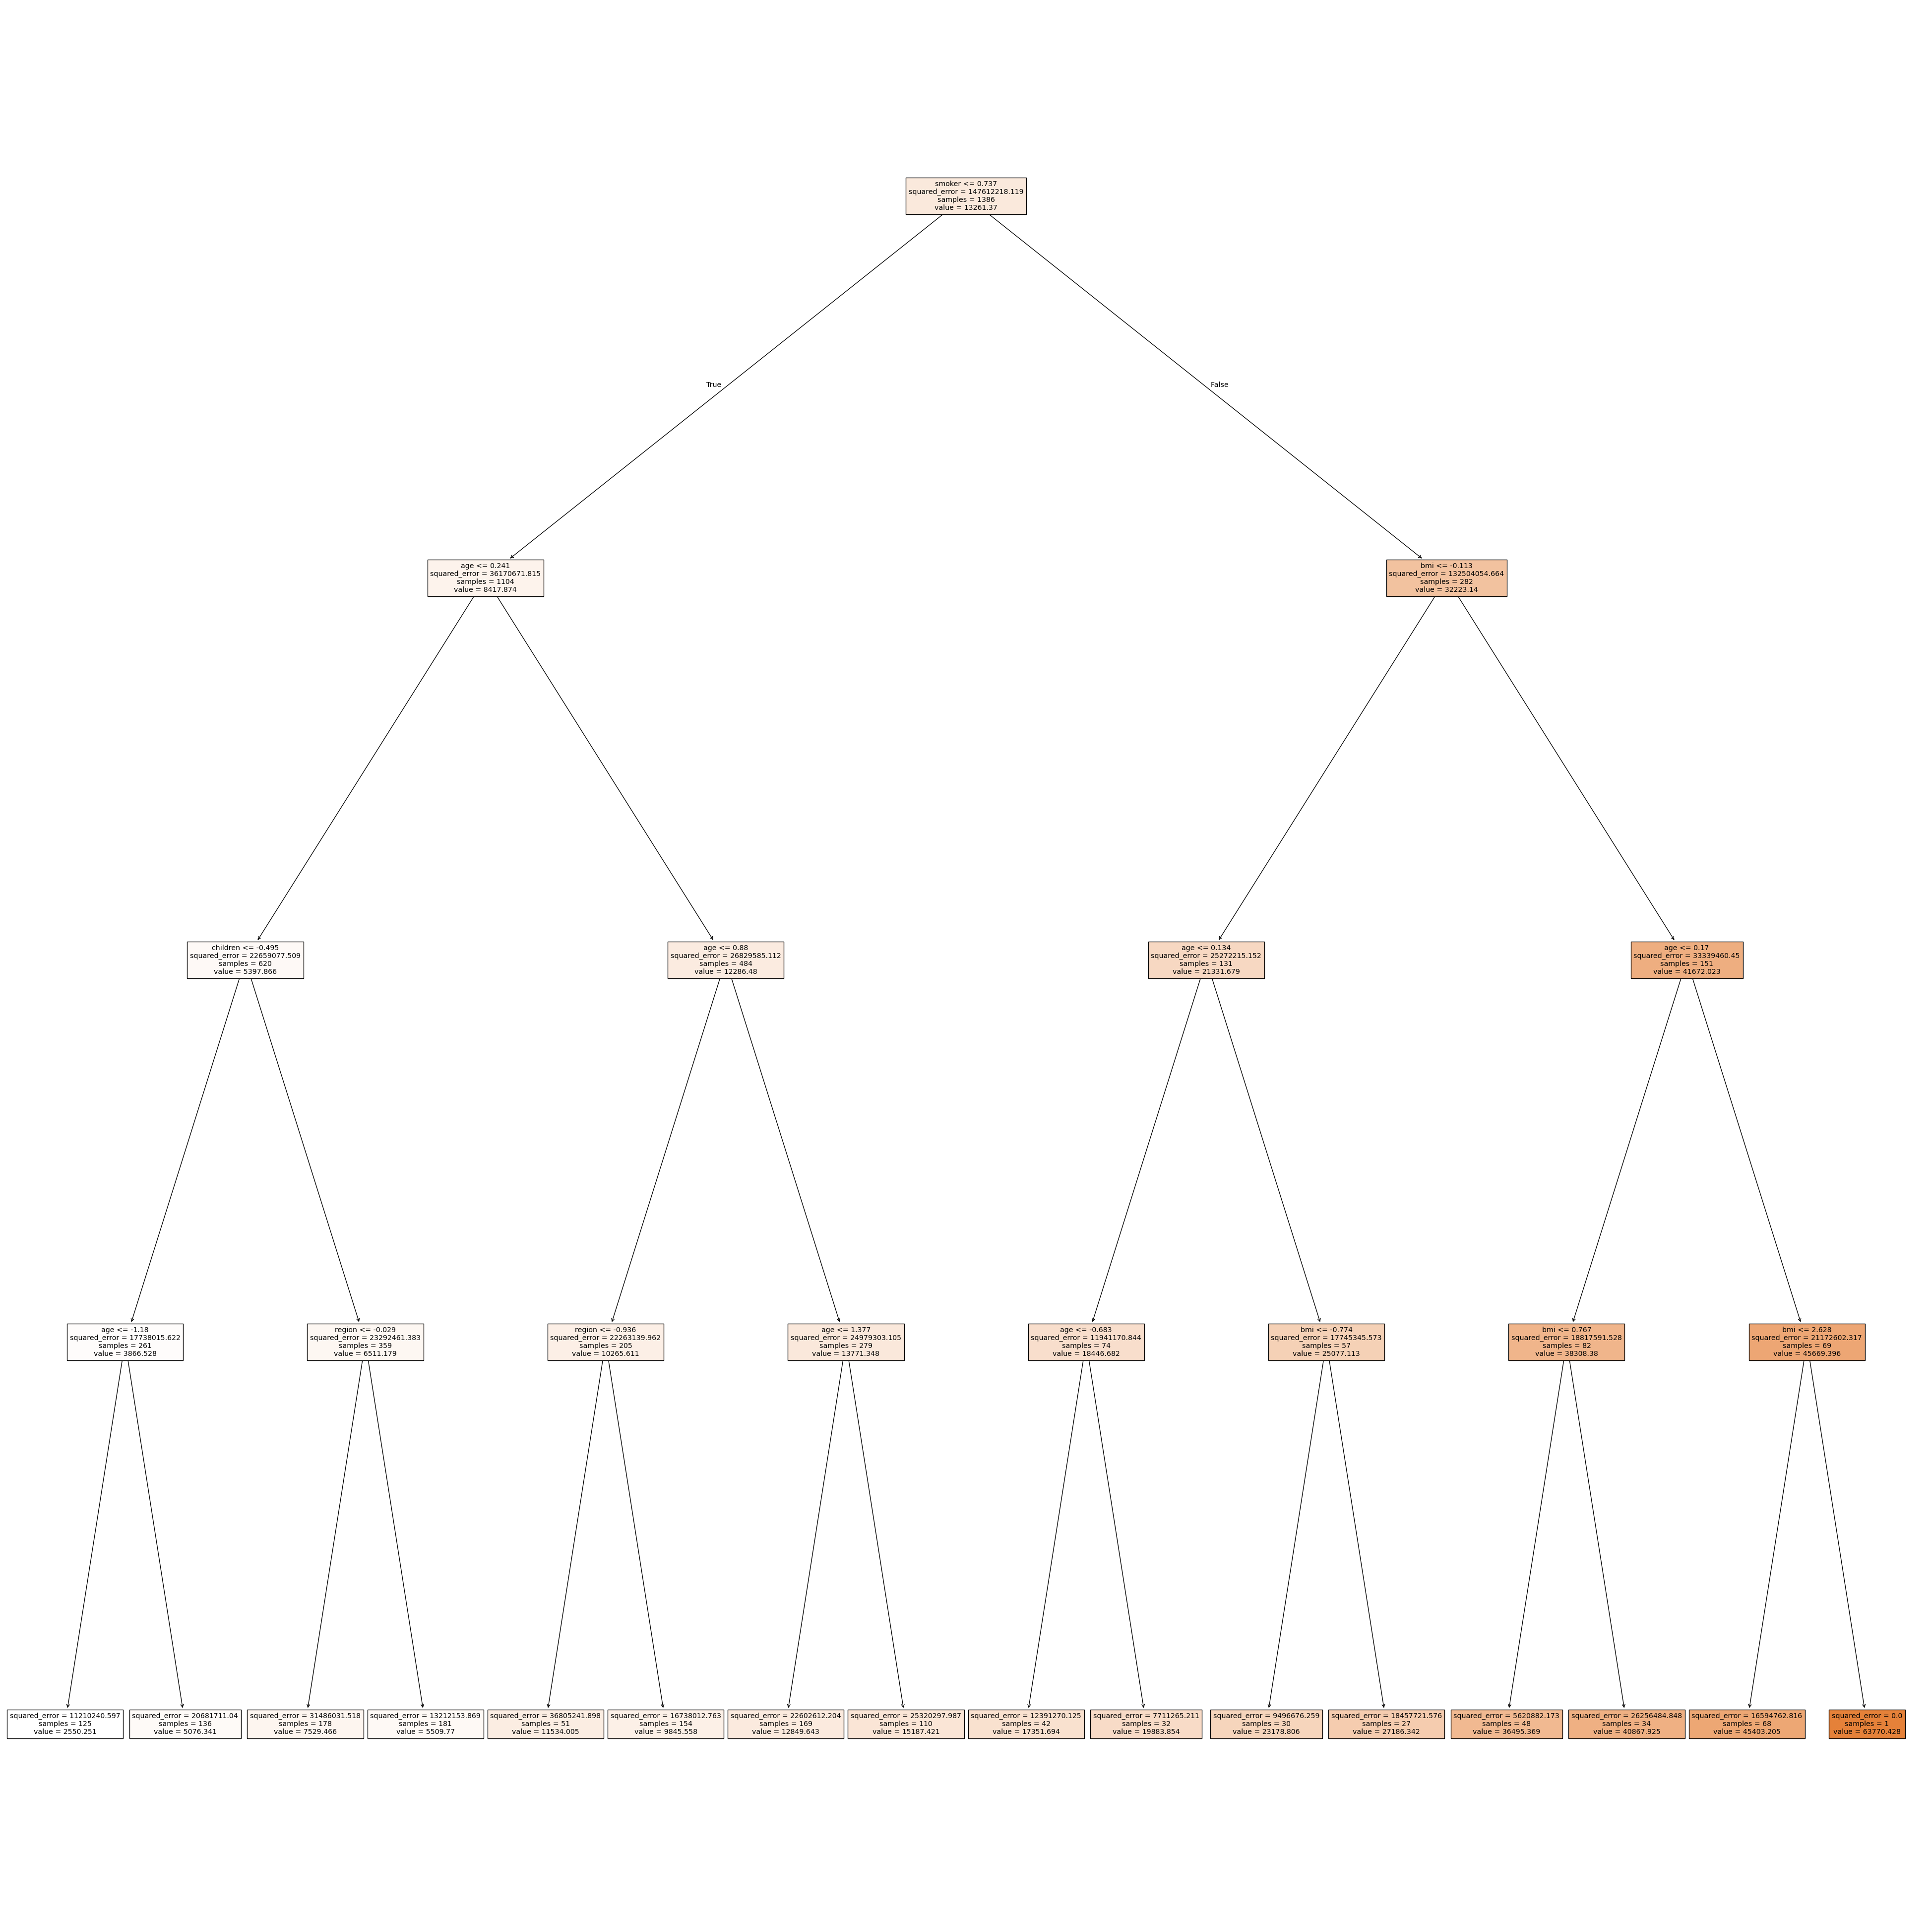

In [53]:
from sklearn.tree import plot_tree
pruned_regressor = DecisionTreeRegressor(max_depth=4)
pruned_regressor.fit(X_train, y_train)


y_pred_pruned = pruned_regressor.predict(X_test)


pruned_Tree_model = plt.figure(figsize=(50,50))
pruned_Tree_model_Graph = plot_tree(pruned_regressor, feature_names=list(X.columns), filled=True)


pruned_Tree_model.savefig("pruned_reg_decision_tree.png")

In [54]:
data = []
data.append( {"age":56.0,
              "sex":1,
              "bmi":29,
              "children":3,
              "smoker":0,
              "region":2} )
df2 = pd.DataFrame(data)


df2["Predicted Medical Insurance Charge"] = pruned_regressor.predict(df2)
df2.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but DecisionTreeRegressor was fitted without feature names



,age,sex,bmi,children,smoker,region,Predicted Medical Insurance Charge
0,56.0,1,29,3,0,2,15187.421285


# **XGBoost:**

In [55]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor()

xgb_model.fit(X_train, y_train)

y_pred4 = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred4)
mse = mean_squared_error(y_test, y_pred4)
r2 = r2_score(y_test, y_pred4)

print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)

Mean Absolute Error: 578.1906660171582
Mean Squared Error: 1113767.1995939242
R-squared: 0.9924547763471735


### **XGBoost GridSearchCV Hyperparameter Tuning:**

In [56]:
params_xgb = {
    'n_estimators' : [100, 200, 300],
    'max_depth' : [3, 6, 9],
    'learning_rate' : [0.01, 0.1, 0.2],
    'gamma' : [0, 0.1, 0.2]
}

In [57]:
from sklearn.model_selection import GridSearchCV
xgb_gs = GridSearchCV(xgb_model, params_xgb, cv=5, n_jobs=-1)
xgb_gs.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'gamma': [0, 0.1, 0.2],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 6, 9],
                         'n_estimators': [100, 200, 300]})

In [58]:
print(xgb_gs.best_estimator_)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)


In [59]:
xgb_gs.best_estimator_.fit(X_train, y_train)
y_pred5 = xgb_gs.best_estimator_.predict(X_test)

mae = mean_absolute_error(y_test, y_pred5)
mse = mean_squared_error(y_test, y_pred5)
r2 = r2_score(y_test, y_pred5)

print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)

Mean Absolute Error: 2143.930860529215
Mean Squared Error: 15720578.83498321
R-squared: 0.8935008291633249


In [60]:
# Prediction with pre-tuned XGBoost model
data = []
data.append( {"age":56.0,
              "sex":1,
              "bmi":29,
              "children":3,
              "smoker":0,
              "region":2} )
df2 = pd.DataFrame(data)


df2["Predicted Medical Insurance Charge"] = xgb_model.predict(df2)
df2.head()

,age,sex,bmi,children,smoker,region,Predicted Medical Insurance Charge
0,56.0,1,29,3,0,2,29279.169922


In [61]:
# Prediction with GridSearchCV hypertuned parameters
data = []
data.append( {"age":56.0,
              "sex":1,
              "bmi":29,
              "children":3,
              "smoker":0,
              "region":2} )
df2 = pd.DataFrame(data)


df2["Predicted Medical Insurance Charge"] = xgb_gs.predict(df2)
df2.head()

,age,sex,bmi,children,smoker,region,Predicted Medical Insurance Charge
0,56.0,1,29,3,0,2,26137.6875
